In [1]:
import pandas as pd
import numpy as np
import scipy.signal as signal
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.dates import DateFormatter, date2num
from matplotlib.lines import Line2D

In [2]:
# CSV for Ground Temperature & Humidity: EM300-TH sensor data.
df_TH = pd.read_csv('thingsboard_EM300-TH-13-10.csv')
# CSV for Soil Moisture, Temperature, and EC: EM500-SMTC sensor data.
df_SMTC = pd.read_csv('thingsboard_EM500-SMTC_13-10.csv')
# CSV for Water Container EM500-UDL sensor data.
df_UDL = pd.read_csv('thingsboard_EM500-UDL_data.csv')
# CSV for normalized water container capacity EM500-UDL sensor data.
df_power = pd.read_csv('thingsboard_UC300_4-20ma.csv')
df_liter = pd.read_csv('container.csv') # For Filled Liter
df_timestamp = pd.read_csv('distance.csv') # For Timestamp
df_water_container = pd.read_csv('water_container.csv') 
df_merged = pd.read_csv('last_merged.csv') 

In [3]:
TH_null = df_TH['time(ns)'].isnull().values.any()
UDL_null = df_UDL['timestamp'].isnull().values.any()
SMTC_null = df_SMTC['time(ns)'].isnull().values.any()
Liter_null = df_liter['timestamp'].isnull().values.any()
print(TH_null, UDL_null, SMTC_null, Liter_null)

df_merged['time(ns)'] = pd.to_datetime(df_merged['time(ns)'])

False False False False


### Merging Dataframes


In [89]:
#df_extract = df_timestamp['timestamp']
#df_liter = pd.concat([df_liter, df_extract.rename('time')], axis=1)

### Converting time object to datetime format 


In [ ]:
#df_liter["time"] = df_liter["time"].astype("datetime64[ns]")
# also use dtype to see the column types


### Removing unnecessary columns


In [ ]:
#df_liter.drop('normalized', axis=1, inplace=True) # normalized, Filled M3, timestamp



### adopting the format of time differences from delta to series


In [ ]:
#df_liter['nano_time'] = df_liter['time_differences'] / np.timedelta64(1,'s')

### Inserting Columns


In [ ]:
#df_liter.insert(3, "y_verification", False)
#df_liter.insert(4, "timestamp_differences", False)
#df_liter.insert(5, "litter_differences", False)
#df_liter.insert(6, "slope", False)

### converting time format to ns


In [ ]:
#df_water_container['timestamp'] = pd.to_datetime(df_water_container['timestamp'])

### converting to a csv


In [ ]:
#df_liter.to_csv('water_container.csv', index=False)

### Calculating differences


In [ ]:
#diff_liter = abs(healthy_slope["Filled Liter"].diff()) 
#diff_time = abs(df_liter["time"].diff()) 

### adding column

In [ ]:
#df_liter.insert(5, "litter_differences", diff_liter, allow_duplicates= False)
#df_liter.insert(5, "time_differences", diff_time, allow_duplicates= False)

### Changing order

In [ ]:
#df_liter[80:120]
#df_liter = df_liter[['time', 'Filled Liter', 'distance', 'time_differences', 'litter_differences']]

### dividing liter by time

In [ ]:

#healthy_slope = pd.read_csv('healthy_slope.csv')
#healthy_slope['slope'] = healthy_slope['liter_differences'] / healthy_slope['nano_time']

### Merging data frames based on their times

In [ ]:
# Default backward merge
#result = pd.merge_asof(df_water_container, df_power, on='time(ns)', direction="nearest")
#print(result)

### Make Boolean conditions based on the value

In [ ]:
"""conditions = [(df_merged['power_on'] > 4.0),(df_merged['power_on'] == 4 )]
choices = [True, False]
df_merged['power_status'] = np.select(conditions, choices, default="NaN")"""

### plotting the outliers for Filled Liter

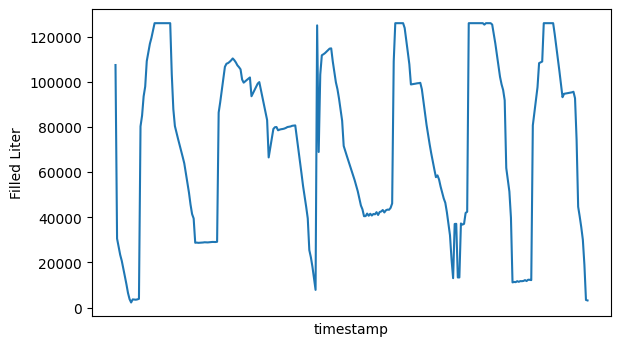

In [ ]:
"""
start_date = '2025-07-18 12:00:00'
end_date = '2025-07-24 12:00:00'

filtered_df = df_water_container[(df_water_container['timestamp'] > start_date) & (df_water_container["timestamp"] < end_date)].copy()

#filtered_df = df_liter[(df_liter['timestamp'] > start_date) & (df_liter["timestamp"] < end_date)].copy()
threshhold = 6.5
filtered_df = filtered_df.loc[filtered_df['slope'] < threshhold]


sns.lineplot(data=filtered_df, x="timestamp", y="Filled Liter")
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.tick_params(
    axis='x',   
    which='both',     
    bottom=False,     
    labelbottom=False 
)
plt.show()"""

### time-based limitation

In [5]:
start_date = '2025-08-05 00:00:00'
end_date = '2025-08-05 23:59:00'
filtered_df = df_water_container[(df_water_container['timestamp'] > start_date) & (df_water_container["timestamp"] < end_date)].copy()
filtered_df = filtered_df.loc[filtered_df['Filled Liter'] > 0]

### finding peaks using scipy

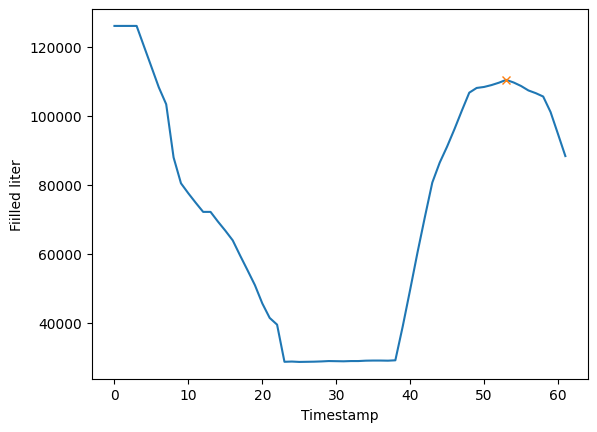

Indices of peaks: [53]
Values of peaks: [110376]
Prominences: [22068.]


In [11]:
x = filtered_df['Filled Liter'].values # .values 
timestamps = filtered_df['timestamp'].values
peaks, properties = signal.find_peaks(x, prominence=(500, None))
df_peaks = filtered_df.iloc[peaks]  # Use iloc to get rows by position
plt.plot(x)

plt.plot(peaks, x[peaks], "x")


plt.xlabel('Timestamp')
plt.ylabel('Fiilled liter')
plt.show()
print("Indices of peaks:", peaks)
print("Values of peaks:", x[peaks])
print("Prominences:", properties['prominences'])

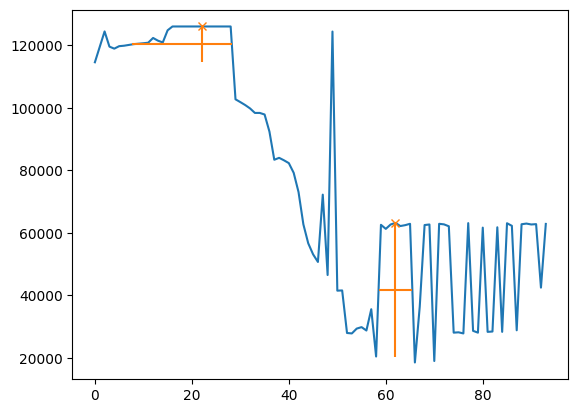

Indices of peaks: [22 62]
Values of peaks: [126000  63180]
Prominences: [11448. 42732.]
width: [20.5314639   6.96797855]


In [7]:
peaks, properties = signal.find_peaks(x, prominence=1000, width=5)
properties["prominences"], properties["widths"]
plt.plot(x)
plt.plot(peaks, x[peaks], "x")
plt.vlines(x=peaks, ymin=x[peaks] - properties["prominences"],
           ymax = x[peaks], color = "C1")
plt.hlines(y=properties["width_heights"], xmin=properties["left_ips"],
           xmax=properties["right_ips"], color = "C1")
plt.show()

print("Indices of peaks:", peaks)
print("Values of peaks:", x[peaks])
print("Prominences:", properties['prominences'])
print("width:", properties['widths'])

### plotting based on an additional value (colored)

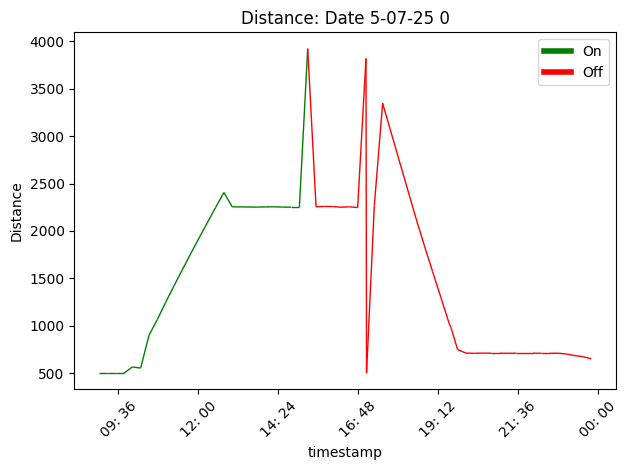

In [ ]:
df_merged = pd.read_csv('last_merged.csv')

start_date='2025-07-25 00:00:00'
end_date = '2025-07-25 23:59:00'

filtered_df = df_merged[(df_merged['time(ns)'] > start_date) & (df_merged["time(ns)"] < end_date)].copy()

x_values = date2num(filtered_df['time(ns)'])
y_values = filtered_df['distance']
power_status = filtered_df['power_status']

points = np.array([x_values, y_values]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

colors = ['green' if cond else 'red' for cond in power_status]

lc = LineCollection(segments, colors=colors, linewidths=1)

fig, ax = plt.subplots()
ax.add_collection(lc)
ax.autoscale()
ax.set_title(f'Distance: Date {str(filtered_df["time(ns)"][:1])[10:19]}')
ax.set_xlabel('timestamp')
ax.set_ylabel('Distance')

custom_lines = [Line2D([0], [0], color='green', lw=4),
                Line2D([0], [0], color='red', lw=4)]
ax.legend(custom_lines, ['On', 'Off'])
ax.xaxis.set_major_formatter(DateFormatter('%H: %M'))


plt.xticks(rotation=45)
plt.tight_layout()



### histplots

<Axes: xlabel='moisture(soil)', ylabel='Count'>

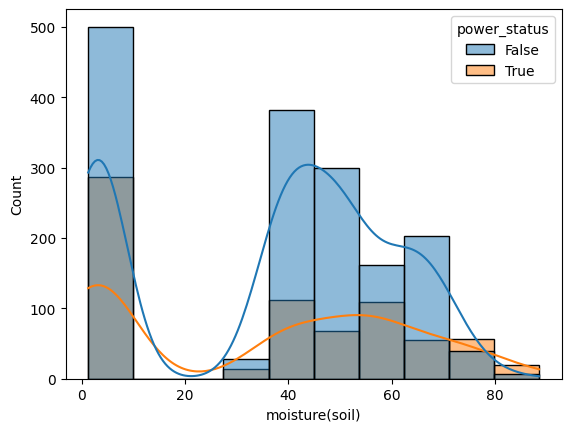

In [5]:
sns.histplot(data=df_merged, 
             x="moisture(soil)", kde=True, bins=10, hue = 'power_status')

<Axes: xlabel='ec(soil)', ylabel='Count'>

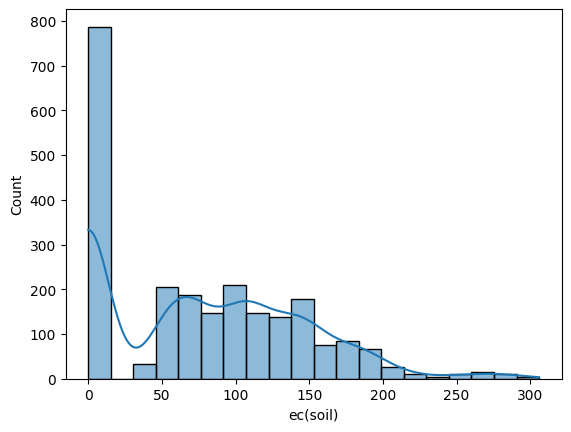

In [6]:
sns.histplot(data=df_merged, 
             x= 'ec(soil)', kde=True, bins=20,stat = "count")

### Plot of the Mean, Max, and Average(moisture)

In [8]:
df_merged['moisture(soil)'].max()

np.float64(88.55)

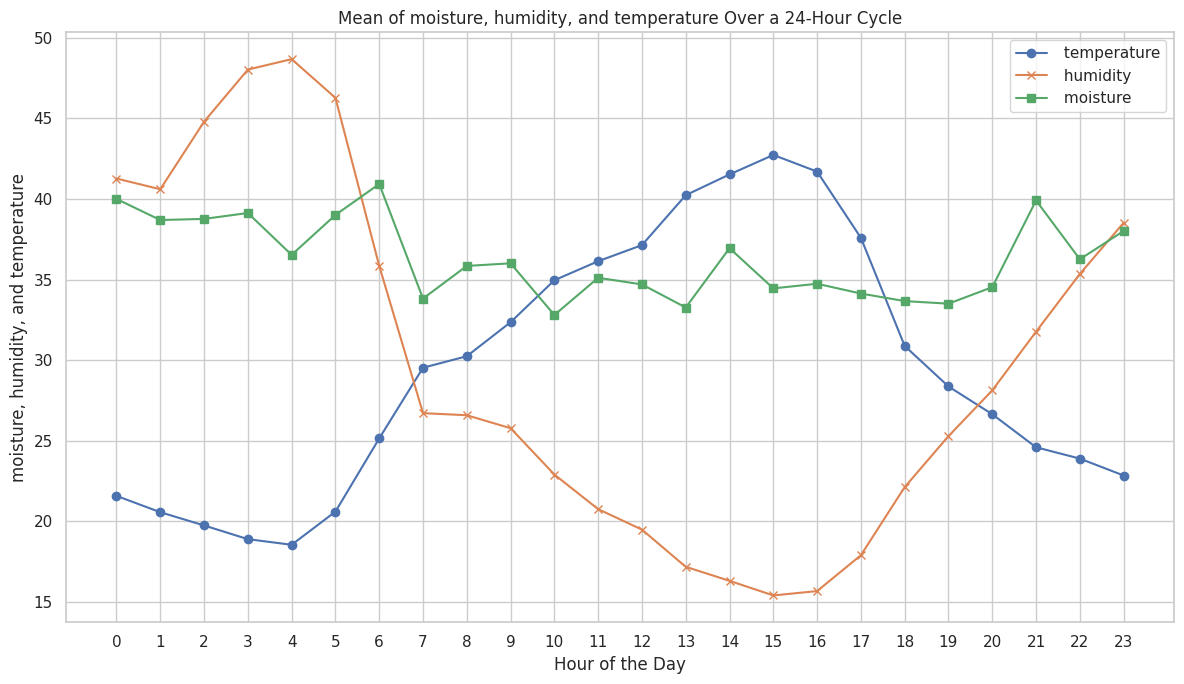

In [ ]:
df_merged['moisture(soil)'] = pd.to_numeric(df_merged['moisture(soil)'], errors='coerce')
df_merged['humidity(above-ground)'] = pd.to_numeric(df_merged['humidity(above-ground)'], errors='coerce')
df_merged['temperature(above-ground)'] = pd.to_numeric(df_merged['temperature(above-ground)'], errors='coerce')

df_merged['timestamp'] = pd.to_datetime(df_merged['timestamp'])
df_merged['hour'] = df_merged['timestamp'].dt.hour

hourly_moisture = df_merged.groupby('hour')['moisture(soil)'].agg(['mean', 'max', 'min']).reset_index()
hourly_humidity = df_merged.groupby('hour')['humidity(above-ground)'].agg(['mean', 'max', 'min']).reset_index()
hourly_temperature = df_merged.groupby('hour')['temperature(above-ground)'].agg(['mean', 'max', 'min']).reset_index()
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))


plt.plot(hourly_moisture['hour'], hourly_temperature['mean'], label=' temperature', marker='o')
plt.plot(hourly_moisture['hour'], hourly_humidity['mean'], label=' humidity', marker='x')
plt.plot(hourly_moisture['hour'], hourly_moisture['mean'], label=' moisture', marker='s')

#plt.plot(hourly_moisture['hour'], hourly_moisture['max'], label='Max moisture', marker='s', linestyle='--')
#plt.plot(hourly_moisture['hour'], hourly_moisture['min'], label='Min moisture', marker='x', linestyle=':')

plt.title('Mean of moisture, humidity, and temperature Over a 24-Hour Cycle')
plt.xlabel('Hour of the Day')
plt.ylabel('moisture, humidity, and temperature')
plt.xticks(range(0, 24))
plt.legend()

plt.tight_layout()

#plt.savefig('hourly_moisture_cycle.png')

### Scatterplot to detect outliers (humidity)

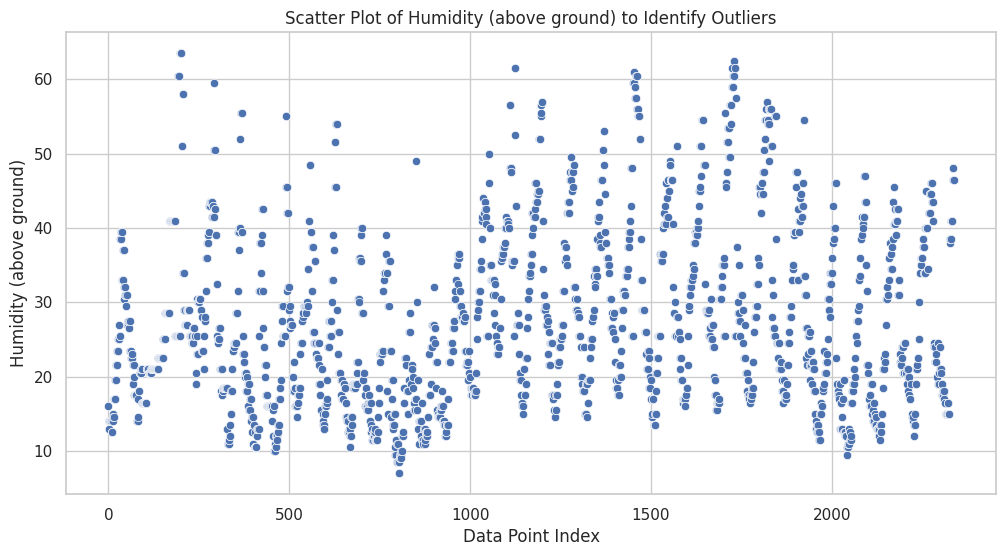

In [5]:

filtered_df = df_merged.copy()
filtered_df['humidity(above-ground)'] = pd.to_numeric(filtered_df['humidity(above-ground)'], errors='coerce')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.scatterplot(x=filtered_df.index, y="humidity(above-ground)", data=filtered_df)

plt.title('Scatter Plot of Humidity (above ground) to Identify Outliers')
plt.xlabel('Data Point Index')
plt.ylabel('Humidity (above ground)')

plt.savefig('humidity_scatter_plot.png')

##### moisture

Text(0, 0.5, 'Soil Temperature')

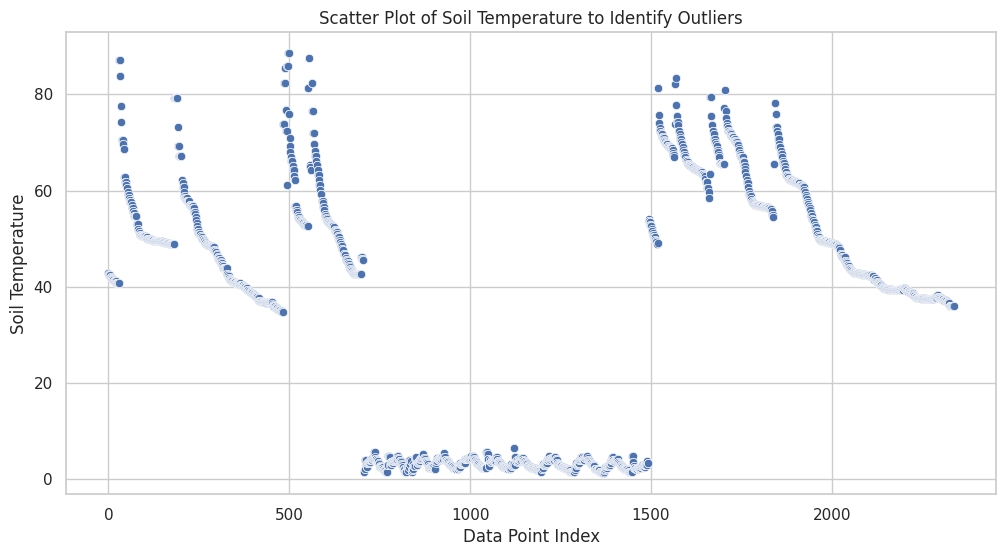

In [6]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df_merged.index, y="moisture(soil)", data=df_merged)

plt.title('Scatter Plot of Soil Temperature to Identify Outliers')
plt.xlabel('Data Point Index')
plt.ylabel('Soil Temperature')

### replacing outliers with median

In [7]:
filtered_df = df_merged.copy()
median_value = filtered_df['humidity(above-ground)'].median()
is_outlier = (filtered_df['humidity(above-ground)'] > 65) 

# Create a new column to store the cleaned data
filtered_df['data_cleaned_median'] = filtered_df['humidity(above-ground)'].copy()

# Replace the outliers with the median value
filtered_df.loc[is_outlier, 'data_cleaned_median'] = median_value

print("Original Data:")
print(filtered_df[['humidity(above-ground)']])
print("\nData with Outliers Replaced by Median:")
print(filtered_df[['data_cleaned_median']])

Original Data:
      humidity(above-ground)
0                       16.0
1                       13.0
2                       13.0
3                       14.0
4                       14.0
...                      ...
2333                    41.0
2334                    48.0
2335                    48.0
2336                    46.5
2337                    46.5

[2338 rows x 1 columns]

Data with Outliers Replaced by Median:
      data_cleaned_median
0                    16.0
1                    13.0
2                    13.0
3                    14.0
4                    14.0
...                   ...
2333                 41.0
2334                 48.0
2335                 48.0
2336                 46.5
2337                 46.5

[2338 rows x 1 columns]


### removing outliers

In [ ]:
df_filtered = pd.read_csv('last_merged.csv')

#df_filtered.iloc[706:1495, df_filtered.columns.get_loc('moisture(soil)')] = np.nan

### plotting moisture

Text(0, 0.5, 'Soil moisture')

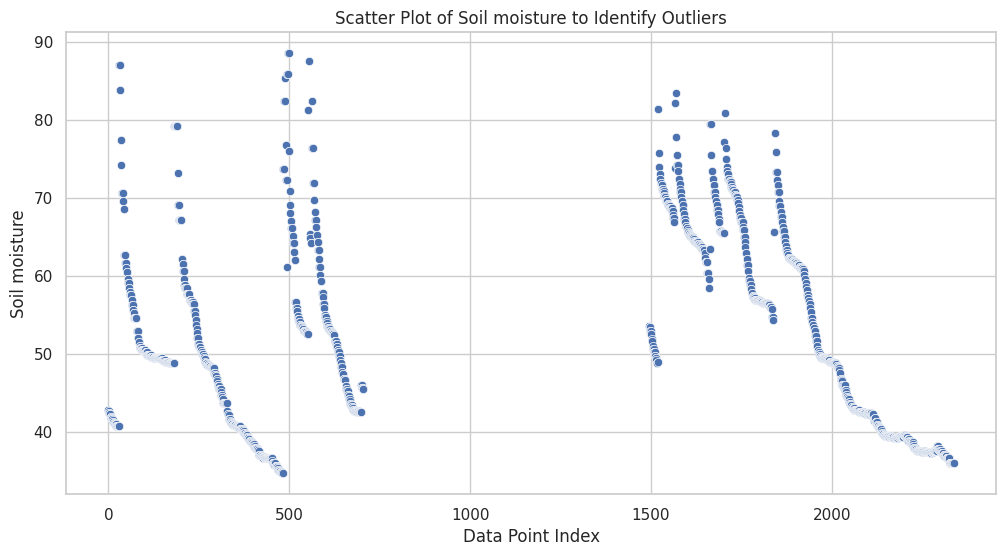

In [14]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df_filtered.index, y="moisture(soil)", data=df_filtered)

plt.title('Scatter Plot of Soil moisture to Identify Outliers')
plt.xlabel('Data Point Index')
plt.ylabel('Soil moisture')

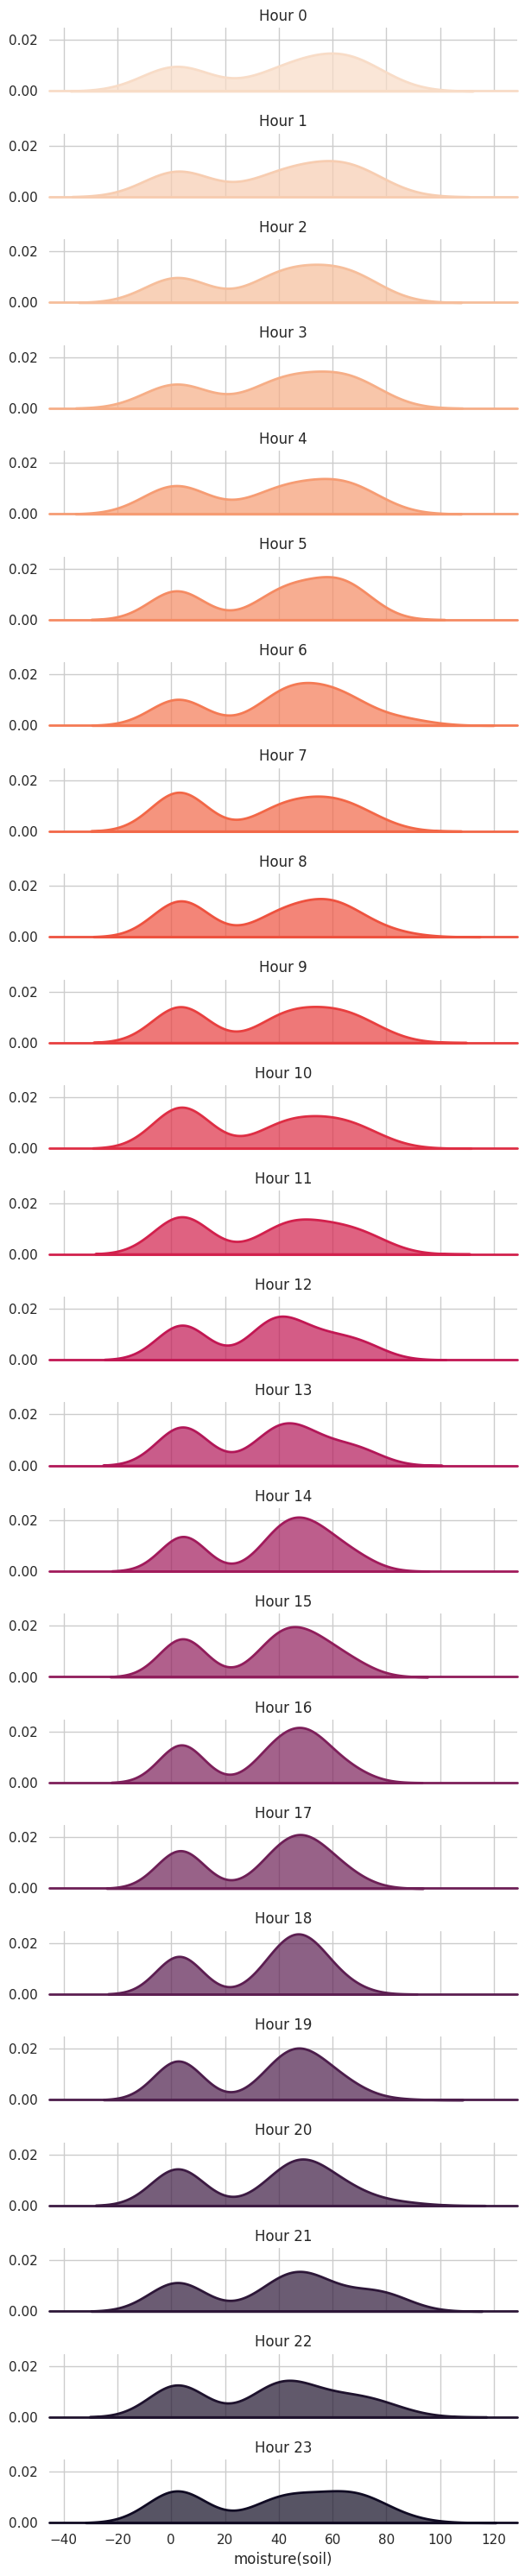

In [ ]:
palette = sns.color_palette("rocket_r", df_merged['hour'].nunique())

# Create the Ridgeline plot
rp = sns.FacetGrid(
    df_merged,
    row="hour",
    hue="hour",
    aspect=5,
    height=1.25,
    palette=palette
)

# Plot the KDE for each hour
rp.map(sns.kdeplot, 'moisture(soil)', clip_on=False, fill=True, alpha=0.7, lw=2)

rp.map(plt.axhline, y=0, lw=2, clip_on=False)

# Customize the plot
rp.fig.subplots_adjust(hspace=0.2)
rp.set_axis_labels('moisture(soil)', "")
rp.set_titles(row_template="Hour {row_name}")
rp.despine(bottom=True, left=True)

plt.tight_layout()
plt.savefig('ridgeline_moisture.png')

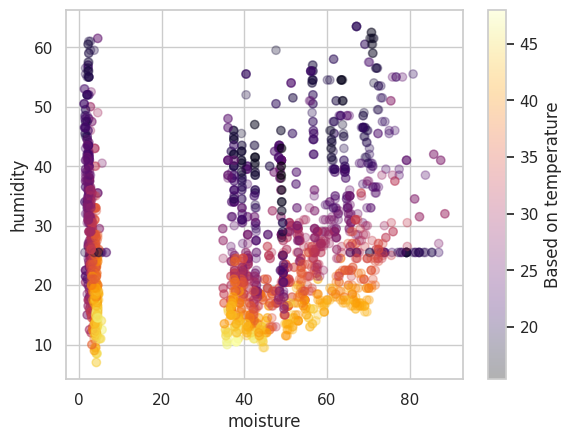

In [ ]:
y = df_merged['humidity(above-ground)']
x = df_merged['moisture(soil)']
colors = df_merged['temperature(above-ground)']

plt.scatter(x, y, c=colors, alpha=0.3, cmap = 'inferno')
plt.xlabel("moisture")
cbar = plt.colorbar()
cbar.set_label('Based on temperature')
plt.ylabel("humidity")
plt.show()
plt.savefig('humidity_moisture_scatter_plot.png')

### finding plot differences

In [10]:
list_moisture = []
list_temperature = []
list_humidity = []
diff_moisture_humidity = []
diff_all = []
for i in range(24):  
    list_moisture.append(int(hourly_moisture['mean'][i]))
    list_humidity.append(int(hourly_humidity['mean'][i]))
    list_temperature.append(int(hourly_temperature['mean'][i]))
    diff_moisture_humidity.append(int(list_moisture[i]) - int(list_humidity[i]))

    diff_all.append(int(diff_moisture_humidity[i]) - int(list_temperature[i]))
"""
print(list_moisture)
print(list_humidity)
print(list_temperature)"""
print(diff_moisture_humidity)
print(diff_all)

[-1, -2, -6, -9, -12, -7, 5, 7, 9, 11, 10, 15, 15, 16, 20, 19, 19, 17, 11, 8, 6, 8, 1, 0]
[-22, -22, -25, -27, -30, -27, -20, -22, -21, -21, -24, -21, -22, -24, -21, -23, -22, -20, -19, -20, -20, -16, -22, -22]


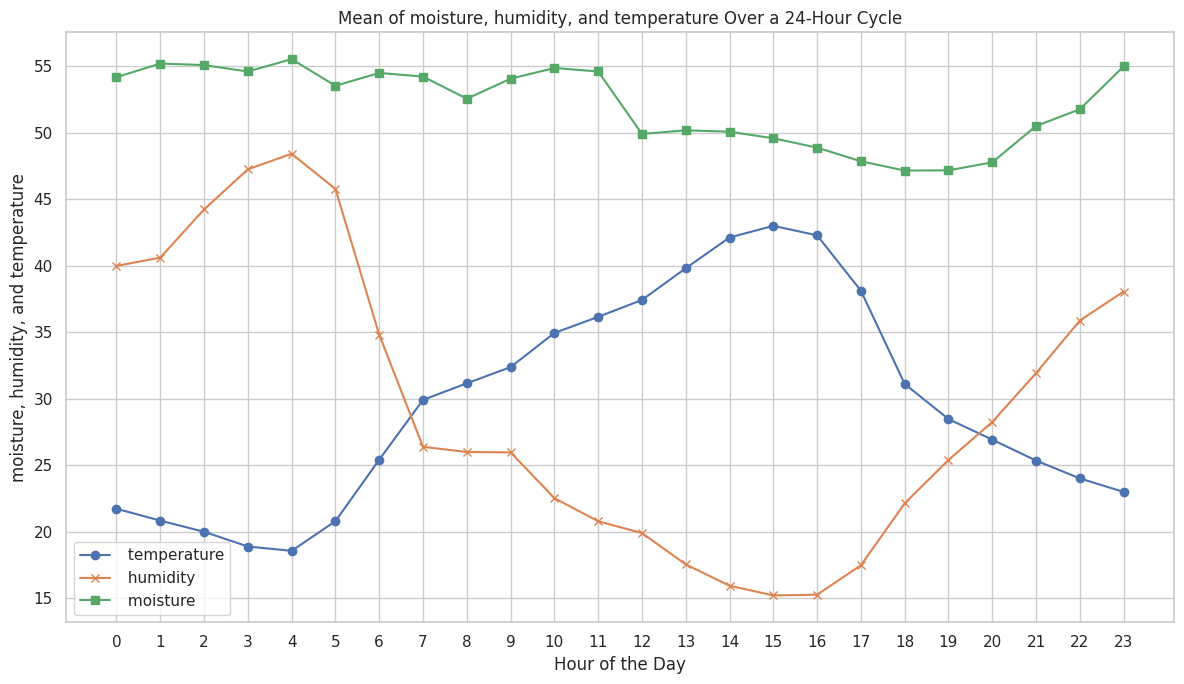

In [ ]:
df_soil_weather = pd.read_csv('moisture_humidity.csv')
df_soil_weather['moisture'] = pd.to_numeric(df_soil_weather['moisture'], errors='coerce')
df_soil_weather['humidity'] = pd.to_numeric(df_soil_weather['humidity'], errors='coerce')
df_soil_weather['temperature(above-ground)'] = pd.to_numeric(df_soil_weather['temperature(above-ground)'], errors='coerce')
df_soil_weather['ec'] = pd.to_numeric(df_soil_weather['ec'], errors='coerce')

df_soil_weather['time(ns)'] = pd.to_datetime(df_soil_weather['time(ns)'])
df_soil_weather['hour'] = df_soil_weather['time(ns)'].dt.hour

hourly_moisture = df_soil_weather.groupby('hour')['moisture'].agg(['mean', 'max', 'min']).reset_index()
hourly_humidity = df_soil_weather.groupby('hour')['humidity'].agg(['mean', 'max', 'min']).reset_index()
hourly_temperature = df_soil_weather.groupby('hour')['temperature(above-ground)'].agg(['mean', 'max', 'min']).reset_index()
hourly_ec = df_soil_weather.groupby('hour')['ec'].agg(['mean', 'max', 'min']).reset_index()
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))


#plt.plot(hourly_ec['hour'], hourly_ec['mean'], label=' electro conductivity', marker='o')
plt.plot(hourly_temperature['hour'], hourly_temperature['mean'], label=' temperature', marker='o')
plt.plot(hourly_humidity['hour'], hourly_humidity['mean'], label=' humidity', marker='x')
plt.plot(hourly_moisture['hour'], hourly_moisture['mean'], label=' moisture', marker='s')

"""
plt.plot(hourly_humidity['hour'], hourly_humidity['max'], label='Max humidity', marker='s', linestyle='--')
plt.plot(hourly_humidity['hour'], hourly_humidity['min'], label='Min humidity', marker='x', linestyle=':')
plt.plot(hourly_temperature['hour'], hourly_temperature['max'], label='Max temperature', marker='s', linestyle='--')
plt.plot(hourly_temperature['hour'], hourly_temperature['min'], label='Min temperature', marker='x', linestyle=':')

"""
#plt.plot(hourly_moisture['hour'], hourly_moisture['max'], label='Max moisture', marker='s', linestyle='--')
#plt.plot(hourly_moisture['hour'], hourly_moisture['min'], label='Min moisture', marker='x', linestyle=':')


plt.title('Mean of moisture, humidity, and temperature Over a 24-Hour Cycle')
plt.xlabel('Hour of the Day')
plt.ylabel('moisture, humidity, and temperature')
plt.xticks(range(0, 24))
plt.legend()

plt.tight_layout()
plt.savefig('main_plot.png')

In [25]:
def output():
    list_moisture = []
    list_temperature = []
    list_humidity = []
    diff_temperature_humidity = []
    diff_all = []
    for i in range(24):  
        list_moisture.append(int(hourly_moisture['mean'][i]))
        list_humidity.append(float(hourly_humidity['mean'][i]))
        list_temperature.append(float(hourly_temperature['mean'][i]))
        diff_temperature_humidity.append(float(list_humidity[i]) - float(list_temperature[i]))

        diff_all.append(int(diff_temperature_humidity[i]) - int(list_temperature[i]))
    """
    print(list_moisture)
    print(list_humidity)
    print(list_temperature)"""
    #print(diff_temperature_humidity)
    #diff_temperature_humidity = diff_temperature_humidity
    for index, item in enumerate(diff_temperature_humidity):
        print(f'hour: {index}, Item: {item:.2f}')
output()

hour: 0, Item: 19.68
hour: 1, Item: 20.03
hour: 2, Item: 25.04
hour: 3, Item: 29.12
hour: 4, Item: 30.12
hour: 5, Item: 25.66
hour: 6, Item: 10.70
hour: 7, Item: -2.82
hour: 8, Item: -3.66
hour: 9, Item: -6.57
hour: 10, Item: -12.05
hour: 11, Item: -15.38
hour: 12, Item: -17.64
hour: 13, Item: -23.05
hour: 14, Item: -25.20
hour: 15, Item: -27.32
hour: 16, Item: -26.01
hour: 17, Item: -19.68
hour: 18, Item: -8.75
hour: 19, Item: -3.08
hour: 20, Item: 1.48
hour: 21, Item: 7.17
hour: 22, Item: 11.45
hour: 23, Item: 15.67


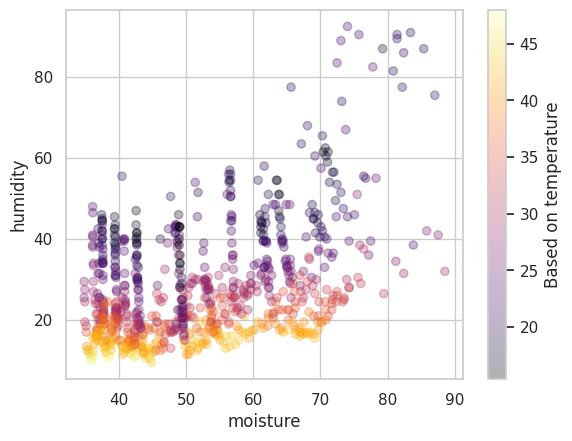

In [12]:
y = df_soil_weather['humidity']
x = df_soil_weather['moisture']
colors = df_soil_weather['temperature(above-ground)']

plt.scatter(x, y, c=colors, alpha=0.3, cmap = 'inferno')
plt.xlabel("moisture")
cbar = plt.colorbar()
cbar.set_label('Based on temperature')
plt.ylabel("humidity")
plt.show()

<Axes: xlabel='humidity', ylabel='moisture'>

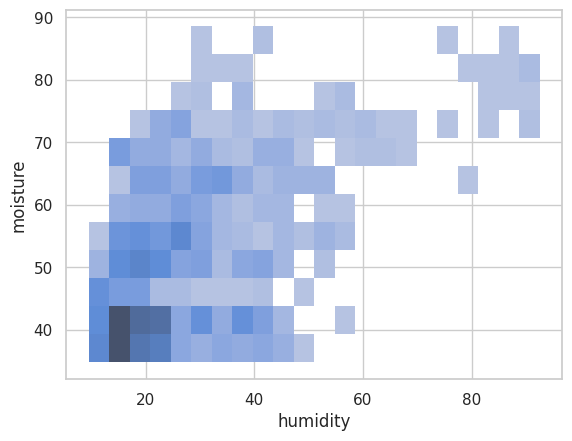

In [ ]:
#penguins = sns.load_dataset("penguins")
sns.histplot(data=df_soil_weather, x="humidity", y = 'moisture')


In [39]:
filtered_df = df_soil_weather.copy()
filtered_df = filtered_df[filtered_df['humidity'] < 65] 


<Axes: xlabel='humidity', ylabel='Count'>

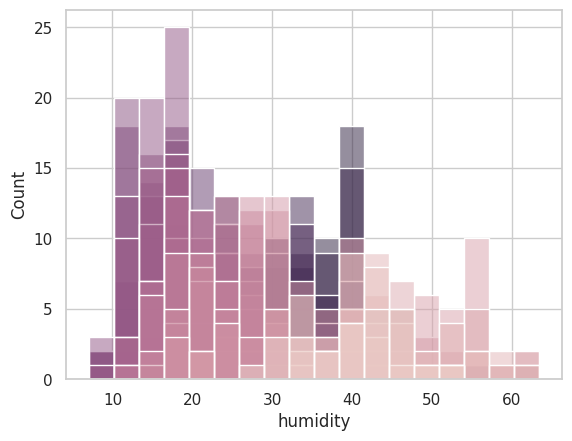

In [ ]:
#penguins = sns.load_dataset("penguins")
sns.histplot(data=filtered_df, x="humidity", hue ='hour', legend=False)
#plt.legend(loc='lower left', ncol=2, fontsize='x-large')

plt.savefig('humidity_histplot.png')